## Customer Ticket Classification

In [1]:
import pandas as pd

df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [2]:
df.shape

(8469, 17)

In [3]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [5]:
df = df[['Ticket Subject',
         'Ticket Description',
         'Ticket Type',
         'Ticket Priority']]

In [6]:
df.head()

,Ticket Subject,Ticket Description,Ticket Type,Ticket Priority
0,Product setup,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,Network problem,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,Account access,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,Data loss,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [7]:
df['Text'] = (
    df['Ticket Subject'].astype(str)
    + " "
    + df['Ticket Description'].astype(str)
)

df[['Text','Ticket Type']].head()

,Text,Ticket Type
0,Product setup I'm having an issue with the {pr...,Technical issue
1,Peripheral compatibility I'm having an issue w...,Technical issue
2,Network problem I'm facing a problem with my {...,Technical issue
3,Account access I'm having an issue with the {p...,Billing inquiry
4,Data loss I'm having an issue with the {produc...,Billing inquiry


In [19]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['Text'] = df['Text'].apply(clean_text)

In [21]:
X = df['Text']

In [25]:
y = df['Ticket Priority']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2)
)

In [30]:
from sklearn.linear_model import LogisticRegression

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(
    max_iter=2000
)

model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.2644628099173554


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [14]:
predictions = model.predict(X_test_tfidf)

print(predictions[:5])

['Billing inquiry' 'Product inquiry' 'Cancellation request'
 'Cancellation request' 'Billing inquiry']


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.14      0.15       357
Cancellation request       0.18      0.19      0.18       327
     Product inquiry       0.18      0.18      0.18       316
      Refund request       0.19      0.21      0.20       345
     Technical issue       0.24      0.26      0.25       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



In [17]:
sample_ticket = [
    "Unable to login to my account. Password reset not working."
]

sample_tfidf = vectorizer.transform(sample_ticket)

prediction = model.predict(sample_tfidf)

print("Predicted Ticket Type:", prediction[0])

Predicted Ticket Type: Billing inquiry


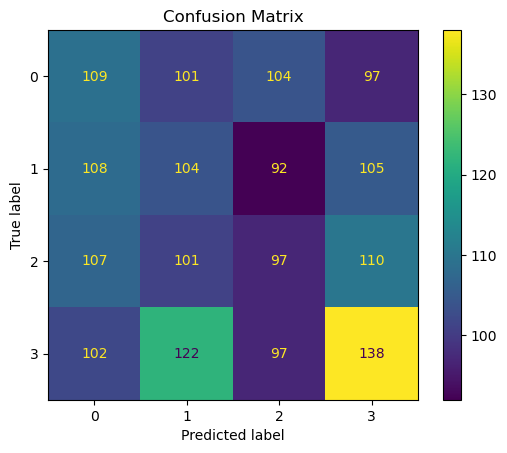

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [28]:
print(df['Ticket Type'].unique())

['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']


In [32]:
print(df['Ticket Priority'].value_counts())

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


## Conclusion

A Support Ticket Classification system was successfully developed using Natural Language Processing (NLP) and Machine Learning techniques. The ticket subject and description were combined and transformed into numerical features using TF-IDF Vectorization. A Logistic Regression model was then trained to classify support tickets into different categories such as Technical Issue, Billing Inquiry, Refund Request, Product Inquiry, and Cancellation Request.

The model achieved an accuracy of 26.45%, demonstrating its ability to identify patterns within customer support tickets and automate the ticket categorization process. Although the accuracy indicates room for improvement, the project successfully showcases the complete NLP workflow, including text preprocessing, feature extraction, model training, prediction, and performance evaluation.

Future enhancements could involve advanced NLP models such as Word Embeddings, Random Forest, BERT, or Transformer-based architectures to improve classification accuracy and better capture the context of customer queries.